In [2]:
import re
import pandas as pd


def parse_can_log(path):
    """
    Parse CAN log lines like:
    (1290000000.012715) can0 230#FD000002D4000400
    Returns a DataFrame with columns: Timestamp (float), ID (hex str), Data (hex str), ID_int (int)
    """
    pattern = re.compile(r'^\((?P<ts>\d+\.\d+)\)\s+\S+\s+(?P<id>[0-9A-Fa-f]+)#(?P<data>[0-9A-Fa-f]+)')
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            m = pattern.match(line.strip())
            if not m:
                continue
            ts = float(m.group('ts'))
            id_hex = m.group('id').upper()
            data_hex = m.group('data').upper()
            try:
                id_int = int(id_hex, 16)
            except ValueError:
                id_int = None
            rows.append((ts, id_hex, data_hex, id_int))
    return pd.DataFrame(rows, columns=['Timestamp', 'ID', 'Data', 'ID_int'])

In [15]:
import os
import json
import pandas as pd

# Load metadata
with open(r"C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\datasets\road_dataset\road\attacks\capture_metadata.json", "r") as f:
    metadata = json.load(f)

def load_attack(log_name):
    """
    Load a ROAD attack log and label injected packets.
    """

    path = os.path.join(
        r"C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks",
        "datasets",
        "road_dataset",
        "road",
        "attacks",
        log_name + ".log"
    )

    # Load log
    df = parse_can_log(path)

    # Use the first timestamp in the capture as the base
    base_timestamp = df["Timestamp"][0]

    # Default label
    df["Attack"] = "R"

    # Look up attack interval
    info = metadata.get(log_name)

    if info is not None and info["injection_interval"] is not None:

        start, end = info["injection_interval"]

        df.loc[
            (df["Timestamp"] >= base_timestamp + start) &
            (df["Timestamp"] <= base_timestamp + end),
            "Attack"
        ] = "T"

    return df



In [16]:
import os

def load_ambient(log_name):
    """
    Load a ROAD ambient log.
    All packets are labelled as Regular ('R').
    """

    path = os.path.join(
        r"C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks",
        "datasets",
        "road_dataset",
        "road",
        "ambient",
        log_name + ".log"
    )

    # Load log
    df = parse_can_log(path)

    # All packets are normal
    df["Attack"] = "R"

    return df

In [17]:
AMBIENT_FOLDER = (
    r"C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks"
    r"\datasets\road_dataset\road\ambient"
)

ambient_dfs = {}

for filename in os.listdir(AMBIENT_FOLDER):

    if not filename.endswith(".log"):
        continue

    log_name = filename[:-4]  # Remove ".log"

    print(f"Loading {log_name}...")

    ambient_dfs[log_name] = load_ambient(log_name)

print(f"\nLoaded {len(ambient_dfs)} ambient datasets.")

Loading ambient_dyno_drive_basic_long...
Loading ambient_dyno_drive_basic_short...
Loading ambient_dyno_drive_benign_anomaly...
Loading ambient_dyno_drive_extended_long...
Loading ambient_dyno_drive_extended_short...
Loading ambient_dyno_drive_radio_infotainment...
Loading ambient_dyno_drive_winter...
Loading ambient_dyno_exercise_all_bits...
Loading ambient_dyno_idle_radio_infotainment...
Loading ambient_dyno_reverse...
Loading ambient_highway_street_driving_diagnostics...
Loading ambient_highway_street_driving_long...

Loaded 12 ambient datasets.


In [18]:
import os

ATTACK_FOLDER = (
    r"C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks"
    r"\datasets\road_dataset\road\attacks"
)

# Dictionary of all attack DataFrames
attack_dfs = {}

for filename in os.listdir(ATTACK_FOLDER):

    # Only load .log files
    if not filename.endswith(".log"):
        continue

    attack_name = filename[:-4]  # Remove ".log"

    print(f"Loading {attack_name}...")

    attack_dfs[attack_name] = load_attack(attack_name)

print(f"\nLoaded {len(attack_dfs)} attack datasets.")

Loading accelerator_attack_drive_1...
Loading accelerator_attack_drive_2...
Loading accelerator_attack_reverse_1...
Loading accelerator_attack_reverse_2...
Loading correlated_signal_attack_1...
Loading correlated_signal_attack_1_masquerade...
Loading correlated_signal_attack_2...
Loading correlated_signal_attack_2_masquerade...
Loading correlated_signal_attack_3...
Loading correlated_signal_attack_3_masquerade...
Loading fuzzing_attack_1...
Loading fuzzing_attack_2...
Loading fuzzing_attack_3...
Loading max_engine_coolant_temp_attack...
Loading max_engine_coolant_temp_attack_masquerade...
Loading max_speedometer_attack_1...
Loading max_speedometer_attack_1_masquerade...
Loading max_speedometer_attack_2...
Loading max_speedometer_attack_2_masquerade...
Loading max_speedometer_attack_3...
Loading max_speedometer_attack_3_masquerade...
Loading reverse_light_off_attack_1...
Loading reverse_light_off_attack_1_masquerade...
Loading reverse_light_off_attack_2...
Loading reverse_light_off_atta

In [19]:
attack_dfs

{'accelerator_attack_drive_1':            Timestamp   ID              Data  ID_int Attack
 0       1.290000e+09  585  0040000000020018    1413      R
 1       1.290000e+09  354  1FFF40000003C580     852      R
 2       1.290000e+09  5E1  893FE0070A000080    1505      R
 3       1.290000e+09  28B  0000000000000000     651      R
 4       1.290000e+09  0A7  005108E5112A00A0     167      R
 ...              ...  ...               ...     ...    ...
 204755  1.290000e+09  153  00000000000C1002     339      R
 204756  1.290000e+09  662  4E60000040000000    1634      R
 204757  1.290000e+09  19C  02FC200002002730     412      R
 204758  1.290000e+09  00E  2054560208087530      14      R
 204759  1.290000e+09  0D0  0273046000000000     208      R
 
 [204760 rows x 5 columns],
 'accelerator_attack_drive_2':            Timestamp   ID              Data  ID_int Attack
 0       1.300000e+09  498  87FFBFFCF9800003    1176      R
 1       1.300000e+09  464  000240000090145A    1124      R
 2       1

In [20]:
import numpy as np

def convert_to_array(df, attack_label='T'):
    ids = df['ID'].to_numpy(dtype=object)
    data = df['Data'].to_numpy(dtype=object)
    attack = df['Attack'].to_numpy(dtype=object)

    samples = np.column_stack((ids, data))
    labels = np.where(attack == 'T', attack_label, 'R').astype(object)

    return samples, labels


In [21]:
def _hex_byte_list_from_row(row):
    if isinstance(row, np.ndarray):
        row = row.tolist()

    if isinstance(row, (list, tuple)):
        if len(row) == 2:
            msg_id, data = row
        elif len(row) == 0:
            raise ValueError("Encountered an empty row")
        else:
            msg_id, data = row[0], row[1]
    else:
        raise ValueError(f"Expected a row-like value, got: {row}")

    msg_id = str(msg_id).strip()
    if len(msg_id) % 2 != 0:
        msg_id = '0' + msg_id

    id_bytes = [int(msg_id[i:i+2], 16) for i in range(0, len(msg_id), 2)]
    data_bytes = []
    for item in str(data).split():
        if not item:
            continue
        try:
            data_bytes.append(int(item, 16))
        except ValueError:
            data_bytes.append(int(item))

    return id_bytes + data_bytes


def convert_windowed_id_data_to_ints(windowed_data, pad_value=0):
    int_windows = []
    for window in windowed_data:
        if isinstance(window, np.ndarray):
            window = window.tolist()

        rows = []
        for row in window:
            rows.append(_hex_byte_list_from_row(row))

        max_len = max(len(r) for r in rows)
        padded_rows = [r + [pad_value] * (max_len - len(r)) for r in rows]
        int_windows.append(padded_rows)
    return int_windows

def format_id_data_windows(windows):
    formatted_all = []
    for window in windows:
        window = np.asarray(window, dtype=object)
        formatted = []
        for msg_id, data in window:
            id_str = str(msg_id).strip().lower().zfill(4)
            data_str = str(data).strip().lower()
            data_str = re.sub(r'[^0-9a-f]', '', data_str)
            if len(data_str) % 2:
                data_str = '0' + data_str
            data_bytes = [data_str[i:i+2] for i in range(0, len(data_str), 2)] if data_str else []
            formatted.append([id_str, ' '.join(data_bytes)])
        formatted_all.append(np.array(formatted, dtype=object))
    return np.array(formatted_all, dtype=object)

In [22]:
attack_train_dfs = {}
attack_test_dfs = {}

attack_train_data = {}
attack_test_data = {}

attack_train_labels = {}
attack_test_labels = {}

for name, df in attack_dfs.items():
    split = int(len(df) * 0.2)

    # Split
    df_test = df.iloc[:split].reset_index(drop=True).copy()
    df_train = df.iloc[split:].reset_index(drop=True).copy()


    # Store dataframes
    attack_train_dfs[name] = df_train
    attack_test_dfs[name] = df_test

    # Convert to arrays
    attack_train_data[name], attack_train_labels[name] = convert_to_array(
        df_train
    )
    attack_train_data[name] = format_id_data_windows([attack_train_data[name]])
    
    # Convert to integer arrays
    attack_train_data[name] = convert_windowed_id_data_to_ints(attack_train_data[name])
    attack_train_data[name] = np.array(attack_train_data[name][0])

    attack_test_data[name], attack_test_labels[name] = convert_to_array(
        df_test
    )

    attack_test_data[name] = format_id_data_windows([attack_test_data[name]])
        
    # Convert to integer arrays
    attack_test_data[name] = convert_windowed_id_data_to_ints(attack_test_data[name])
    attack_test_data[name] = np.array(attack_test_data[name][0])

In [23]:
ambient_train_dfs = {}
ambient_test_dfs = {}

ambient_train_data = {}
ambient_test_data = {}

ambient_train_labels = {}
ambient_test_labels = {}

for name, df in ambient_dfs.items():
    split = int(len(df) * 0.2)

    df_test = df.iloc[:split].reset_index(drop=True).copy()
    df_train = df.iloc[split:].reset_index(drop=True).copy()

    ambient_train_dfs[name] = df_train
    ambient_test_dfs[name] = df_test

    ambient_train_data[name], ambient_train_labels[name] = convert_to_array(
        df_train, attack_label="R"
    )

    ambient_train_data[name] = format_id_data_windows([ambient_train_data[name]])
        
    # Convert to integer arrays
    ambient_train_data[name] = convert_windowed_id_data_to_ints(ambient_train_data[name])
    ambient_train_data[name] = np.array(ambient_train_data[name][0])

    ambient_test_data[name], ambient_test_labels[name] = convert_to_array(
        df_test, attack_label="R"
    )

    ambient_test_data[name] = format_id_data_windows([ambient_test_data[name]])
            
    # Convert to integer arrays
    ambient_test_data[name] = convert_windowed_id_data_to_ints(ambient_test_data[name])
    ambient_test_data[name] = np.array(ambient_test_data[name][0])

In [24]:
ambient_train_data

{'ambient_dyno_drive_basic_long': array([[ 15, 255,   0, ...,   0,   0,   0],
        [  4, 152, 132, ..., 128, 239,  66],
        [  2, 149,   0, ...,   0,  24,  64],
        ...,
        [  2, 116,   0, ..., 124, 129, 221],
        [  1,   7,   0, ...,   0,   0,   0],
        [ 15, 255,   0, ...,   0,   0,   0]], shape=(2393018, 10)),
 'ambient_dyno_drive_basic_short': array([[  5,  34, 223, ...,  72,   0,  28],
        [  3, 102, 126, ...,  71, 206,  56],
        [  5, 128,   0, ..., 135, 237,  32],
        ...,
        [ 15, 255,   0, ...,   0,   0,   0],
        [  2, 149,   0, ...,   0,   0,  64],
        [  6,  98,  79, ...,   0,   0,   0]], shape=(850900, 10)),
 'ambient_dyno_drive_benign_anomaly': array([[  0, 186,   4, ...,   6,   3, 104],
        [  0, 167,   0, ...,   5,  48, 160],
        [  1, 202,  63, ...,   0,  13,  40],
        ...,
        [  0,  61,   0, ...,   0,   0,   0],
        [  2, 193,   1, ...,  31,  28, 222],
        [  1,  37, 144, ...,  96,  79,  96]], s

In [25]:
import os
import pickle

# Create folder if it doesn't already exist
SAVE_DIR = "saved_data"
os.makedirs(SAVE_DIR, exist_ok=True)

# Save dataframes
with open(os.path.join(SAVE_DIR, "attack_train_dfs.pkl"), "wb") as f:
    pickle.dump(attack_train_dfs, f)

with open(os.path.join(SAVE_DIR, "attack_test_dfs.pkl"), "wb") as f:
    pickle.dump(attack_test_dfs, f)

with open(os.path.join(SAVE_DIR, "ambient_train_dfs.pkl"), "wb") as f:
    pickle.dump(ambient_train_dfs, f)

with open(os.path.join(SAVE_DIR, "ambient_test_dfs.pkl"), "wb") as f:
    pickle.dump(ambient_test_dfs, f)

# Save converted data
with open(os.path.join(SAVE_DIR, "attack_train_data.pkl"), "wb") as f:
    pickle.dump(attack_train_data, f)

with open(os.path.join(SAVE_DIR, "attack_test_data.pkl"), "wb") as f:
    pickle.dump(attack_test_data, f)

with open(os.path.join(SAVE_DIR, "ambient_train_data.pkl"), "wb") as f:
    pickle.dump(ambient_train_data, f)

with open(os.path.join(SAVE_DIR, "ambient_test_data.pkl"), "wb") as f:
    pickle.dump(ambient_test_data, f)

# Save labels
with open(os.path.join(SAVE_DIR, "attack_train_labels.pkl"), "wb") as f:
    pickle.dump(attack_train_labels, f)

with open(os.path.join(SAVE_DIR, "attack_test_labels.pkl"), "wb") as f:
    pickle.dump(attack_test_labels, f)

with open(os.path.join(SAVE_DIR, "ambient_train_labels.pkl"), "wb") as f:
    pickle.dump(ambient_train_labels, f)

with open(os.path.join(SAVE_DIR, "ambient_test_labels.pkl"), "wb") as f:
    pickle.dump(ambient_test_labels, f)

print(f"All datasets saved successfully to '{SAVE_DIR}/'")

All datasets saved successfully to 'saved_data/'


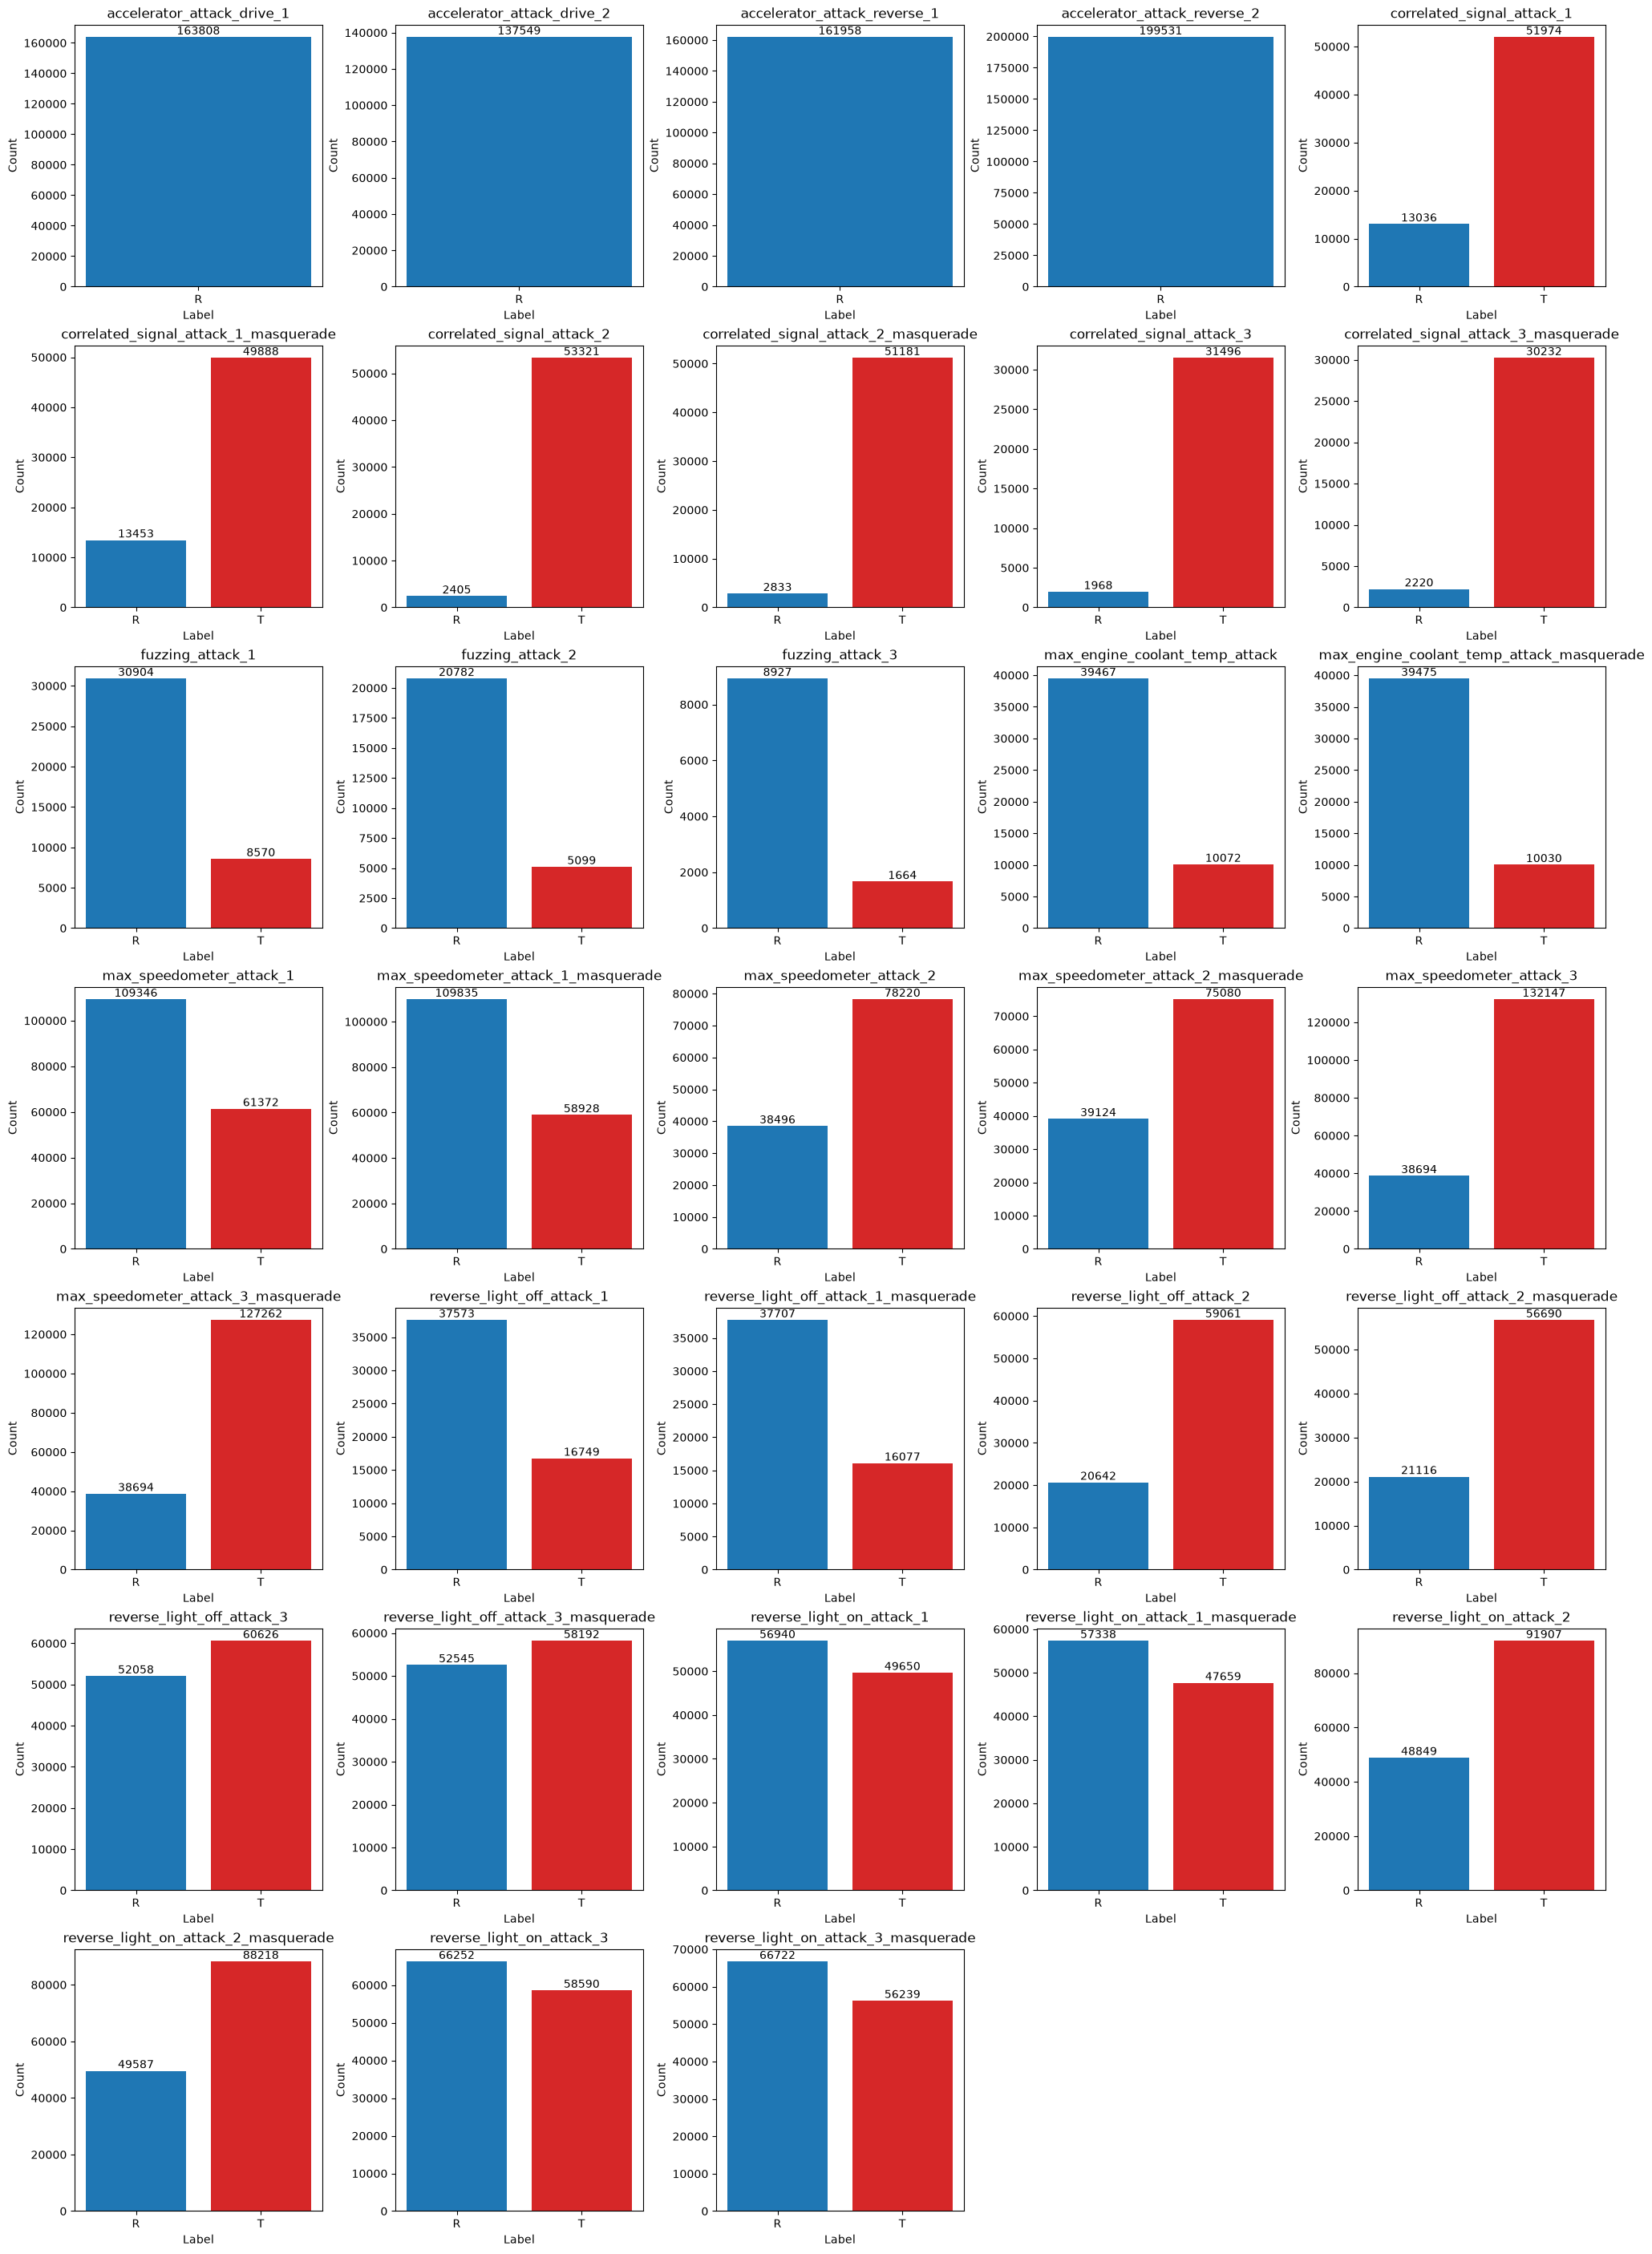

In [26]:
import numpy as np

import matplotlib.pyplot as plt

labels_dict = attack_train_labels
n = len(labels_dict)
cols = 5
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows), constrained_layout=True)
axes = axes.flatten()

for ax, (name, labels) in zip(axes, labels_dict.items()):
    values, counts = np.unique(labels, return_counts=True)
    colors = ['tab:blue' if v == 'R' else 'tab:red' for v in values]
    ax.bar(values, counts, color=colors)
    ax.set_title(name)
    ax.set_xlabel("Label")
    ax.set_ylabel("Count")
    for i, c in enumerate(counts):
        ax.text(i, c, str(c), ha="center", va="bottom")

for ax in axes[n:]:
    ax.axis("off")

plt.show()